# Task 1: News Topic Classifier Using BERT

**Objective:** Fine-tune `bert-base-uncased` to classify AG News headlines into 4 topic categories: World, Sports, Business, Sci/Tech.

**Dataset:** AG News Dataset (Hugging Face Datasets)

**Run this notebook in Google Colab with a GPU runtime:**
`Runtime > Change runtime type > Hardware accelerator > T4 GPU`

## 1. Install Dependencies

In [1]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


## 2. Imports

In [2]:
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import accuracy_score, f1_score

print("GPU available:", torch.cuda.is_available())

GPU available: True


## 3. Load Dataset (AG News)

In [4]:
dataset = load_dataset("fancyzhx/ag_news")
print(dataset)

label_names = dataset["train"].features["label"].names
print("Classes:", label_names)

train_dataset = dataset["train"].shuffle(seed=42).select(range(8000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(2000))

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


## 4. Tokenization

In [5]:
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## 5. Load Pretrained BERT for Sequence Classification

In [6]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(label_names)
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Define Evaluation Metrics

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

## 7. Training Arguments + Trainer

In [9]:
training_args = TrainingArguments(
    output_dir="./bert-news-classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

## 8. Fine-Tune the Model

This will take roughly 10–20 minutes on a free Colab T4 GPU with the 8,000-sample subset.

In [10]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.278936,0.309914,0.903000,0.902726
2,0.246216,0.298195,0.913500,0.913602
3,0.099996,0.332257,0.915000,0.915020


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1500, training_loss=0.24100042629241944, metrics={'train_runtime': 512.9427, 'train_samples_per_second': 46.789, 'train_steps_per_second': 2.924, 'total_flos': 1142128044819840.0, 'train_loss': 0.24100042629241944, 'epoch': 3.0})

## 9. Final Evaluation

In [11]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.099996,0.332257,3,0.915000,0.915020


{'eval_loss': 0.3322572708129883, 'eval_accuracy': 0.915, 'eval_f1': 0.9150195485176997}


## 10. Confusion Matrix / Per-Class Breakdown

              precision    recall  f1-score   support

       World       0.92      0.93      0.93       497
      Sports       0.98      0.97      0.98       483
    Business       0.90      0.86      0.88       522
    Sci/Tech       0.86      0.90      0.88       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



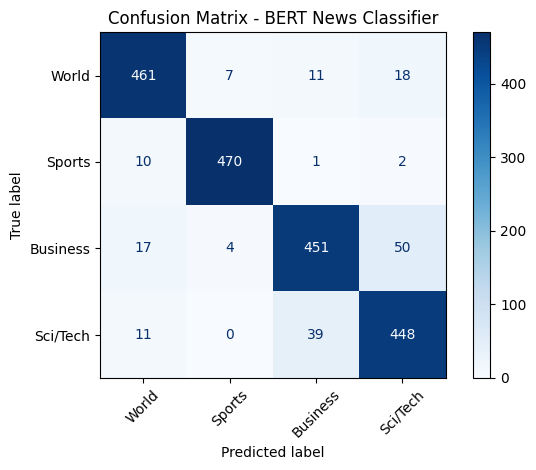

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

preds_output = trainer.predict(test_tokenized)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - BERT News Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

## 11. Save the Fine-Tuned Model

In [13]:
SAVE_PATH = "./outputs/bert-news-classifier-final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print("Model saved to", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./outputs/bert-news-classifier-final


## 12. Quick Inference Test

In [14]:
from transformers import pipeline

classifier = pipeline("text-classification", model=SAVE_PATH, tokenizer=SAVE_PATH)

sample_headlines = [
    "Stocks rally as tech earnings beat expectations",
    "National team wins championship after dramatic final",
    "New satellite launched to study climate change",
    "Government announces new policy on foreign trade",
]

for headline in sample_headlines:
    result = classifier(headline)[0]
    print(f"{headline}\n -> {result}\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Stocks rally as tech earnings beat expectations
 -> {'label': 'LABEL_2', 'score': 0.9143298864364624}

National team wins championship after dramatic final
 -> {'label': 'LABEL_1', 'score': 0.9703179001808167}

New satellite launched to study climate change
 -> {'label': 'LABEL_3', 'score': 0.9898459911346436}

Government announces new policy on foreign trade
 -> {'label': 'LABEL_2', 'score': 0.6579506397247314}



## 13. Download Outputs

Run the cell below to download the confusion matrix image. Then use **File > Download > Download .ipynb** to get this completed notebook for your GitHub repo.

In [15]:
from google.colab import files
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Summary / Insights

- **Accuracy:** [0.915000]
- **F1-score:** [0.915020]